In [23]:
import pandas as pd 
import sklearn as sk
import os
import pandas as pd
import numpy as np 
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import scanpy as sc
import anndata as ad
import bbknn
from sklearn.decomposition import PCA
import numpy as np
import harmonypy as hm
GENE_PANEL = ["ATOH1","DLL1","DLL4","GFI1","AREG","HES1","HES5","JAG2","NOTCH1","NOTCH2","NOTCH3",
              "OLFM4","LEF1","APCDD1","WNT6","NEUROG3","NEUROD1","KRT20","NEURL1","LGR5"]
S_GENES = [
    "MCM5","PCNA","TYMS","FEN1","MCM2","MCM4","RRM1","UNG","GINS2","MCM6","CDCA7",
    "DTL","PRIM1","UHRF1","HELLS","RFC2","RPA2","NASP","RAD51AP1","GMNN","WDR76",
    "SLBP","CCNE2","UBR7","POLD3","MSH2","ATAD2","RAD51","RRM2","CDC45","CDC6",
    "EXO1","TIPIN","DSCC1","BLM","CASP8AP2","USP1","CLSPN","POLA1","CHAF1B","BRIP1",
    "E2F8"
]
G2M_GENES = [
    "HMGB2","CDK1","NUSAP1","UBE2C","BIRC5","TPX2","TOP2A","NDC80","CKS2","NUF2",
    "CKS1B","MKI67","TMPO","CENPF","TACC3","SMC4","CCNB2","CKAP2L","CKAP2","AURKB",
    "BUB1","KIF11","ANP32E","TUBB4B","GTSE1","KIF20B","HJURP","CDCA3","CDC20","TTK",
    "CDC25C","KIF2C","RANGAP1","NCAPD2","DLGAP5","CDCA2","CDCA8","ECT2","KIF23",
    "HMMR","AURKA","PSRC1","ANLN","LBR","CKAP5","CENPE","CTCF","NEK2","G2E3",
    "GAS2L3","CBX5","CENPA"
]


In [24]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat'
train_id=['CRC1502','CRC1620','CRC1139']
tratt_cercato=['cetux','CTX72h']
train=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    trattamento=str.split(file,sep='_')[5]
    if sample_name in train_id and trattamento in tratt_cercato:
        print(file)
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=trattamento
        data.reset_index(drop=True,inplace=True)
        train=pd.concat([train,data])

filtered_annotated_saver_ribomito_CRC1502_cetux_1_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC1139_cetux_1_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC1620_cetux_1_log2_pc1_cpm.csv


In [4]:
cycle_genes = set(S_GENES).union(set(G2M_GENES))

In [25]:
from func_NT_cetux import *
n_hvg=1500
df=train
df_clean, dup = strip_prefix_from_genes(df, meta_cols=("cell_id","sample"), sep=":", on_duplicate="first")

# 2) AnnData + raw
adata_full = make_anndata_from_df(df_clean, set_raw=True)

# 3) cell cycle
score_cell_cycle(adata_full)

#genes_to_keep = [g for g in adata_full.var_names if g not in cycle_genes]

#adata_full = adata_full[:, genes_to_keep].copy()

# 4) HVG + PCA
select_hvg_cell_ranger(adata_full, n_top_genes=n_hvg, batch_key="sample", subset=True)
scale_and_pca(adata_full, n_comps=42, max_value=10, random_state=42)
adata_base = adata_full

BEST = dict(
    n_pcs=20,          # PC da usare per BBKNN
    nwb=3,             # neighbors_within_batch
    trim=None,         # None oppure un intero (es. 12)
    leiden_res=0.3,    # granularità (resolution) per Leiden
    out_root="./bbknn_cetux_KRAS"
)


# cartella output
def safe(s): return re.sub(r"[^A-Za-z0-9_=.,+-]", "_", str(s))
outdir = os.path.join(
    BEST["out_root"],
    f"npcs={BEST['n_pcs']}__nwb={BEST['nwb']}__trim={BEST['trim']}__res={BEST['leiden_res']}"
)
os.makedirs(outdir, exist_ok=True)
sc.settings.figdir = outdir

# 5)integrazione
adx = adata_base.copy()
bbknn.bbknn(
    adx,
    batch_key="sample",
    neighbors_within_batch=BEST['nwb'],
    trim=BEST["trim"],
    n_pcs=BEST["n_pcs"]
)
sc.tl.umap(adx, min_dist=0.3, random_state=42)  # UMAP usa il grafo BBKNN
save_umap_gene_panel(adx, outdir, GENE_PANEL)
# 6)clustering (Leiden)
clu_key = f"leiden_r{BEST['leiden_res']}"
sc.tl.leiden(adx, resolution=BEST["leiden_res"], key_added=clu_key, random_state=42)

# plot rapidi &
sc.pl.umap(adx, color=["sample", clu_key], ncols=2, wspace=0.3, frameon=False,
           show=False, save="_sample+cluster.png")
if "phase" in adx.obs:
    sc.pl.umap(adx, color=["phase"], frameon=False, show=False, save="_phase.png")

saving figure to file bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/umap_genes_panel.png
saving figure to file bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/umap_sample+cluster.png
saving figure to file bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/umap_phase.png


In [26]:
sc.tl.rank_genes_groups(adx, groupby=clu_key, method="wilcoxon", use_raw=adx.raw is not None)
sc.pl.rank_genes_groups(adx, n_genes=25, sharey=False, show=False, save=f"_{clu_key}_top25.png")
data_marker=sc.get.rank_genes_groups_df(adx, None)

saving figure to file bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/rank_genes_groups_leiden_r0.3_leiden_r0.3_top25.png


In [27]:
df_all_sorted = (data_marker
                 .sort_values(["group", "logfoldchanges"], ascending=[True, False], na_position="last")
                )

outdir_mark = os.path.join(outdir, f"markers_{clu_key}_FULL")
os.makedirs(outdir_mark, exist_ok=True)

for grp, df_g in df_all_sorted.groupby("group", sort=False):
    sub = df_g[["names", "logfoldchanges"]].rename(
        columns={"names": "gene", "logfoldchanges": "logfoldchange"}
    )
    sub.to_csv(os.path.join(outdir_mark, f"markers_{clu_key}__{safe(grp)}.csv"), index=False)
df_all_simple = df_all_sorted[["group", "names", "logfoldchanges"]].rename(
    columns={"names": "gene", "logfoldchanges": "logfoldchange"}
)
df_all_simple.to_csv(os.path.join(outdir_mark, f"markers_{clu_key}__ALL.csv"), index=False)

/tmp/ipykernel_270505/1491903864.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for grp, df_g in df_all_sorted.groupby("group", sort=False):


In [28]:
data_obs = pd.DataFrame(adx.obs)

#aggiungo umap alle obs perche di default sta nel obsm
data_obs["umap_1"] = adx.obsm["X_umap"][:, 0]
data_obs["umap_2"] = adx.obsm["X_umap"][:, 1]

# Salva tutto in un CSV
data_obs.to_csv(
    path_or_buf="bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data_with_umap.csv",
    index=False
)

In [55]:
adx

AnnData object with n_obs × n_vars = 12947 × 1500
    obs: 'cell_id', 'sample', 'trattamento', 'uid', 'S_score', 'G2M_score', 'phase', 'leiden_r0.3'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'leiden_r0.3', 'sample_colors', 'leiden_r0.3_colors', 'phase_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [30]:

hvg_genes = adx.var_names[adx.var['highly_variable']]
hvg_genes.to_series().to_csv("bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/highly_variable_genes.csv", index=False, header=["gene"])


In [11]:
data_cetux_path='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data_with_umap.csv'
data=pd.read_csv(data_cetux_path)
data_mixed_path='bbknn_cetux_KRAS_nocorr/npcs=20__nwb=3__trim=None__res=0.3/obs_data_with_umap.csv'
data_nocc=pd.read_csv(data_mixed_path)

UID in comune: 12947  |  out: 12947  |  out_mixed: 12947
cluster_mixed     0     1     2     3     4    5
cluster_orig                                    
0                22  2650   294     0    19    3
1               145    26  2254     1     8   16
2                73     1     0  1875     0   46
3              1639   148    26    37    36    0
4                 0    18     7     0  1675    1
5              1307     0     1    59     1   38
6                33     2    31     0     1  454


<Axes: xlabel='cluster_mixed', ylabel='cluster_orig'>

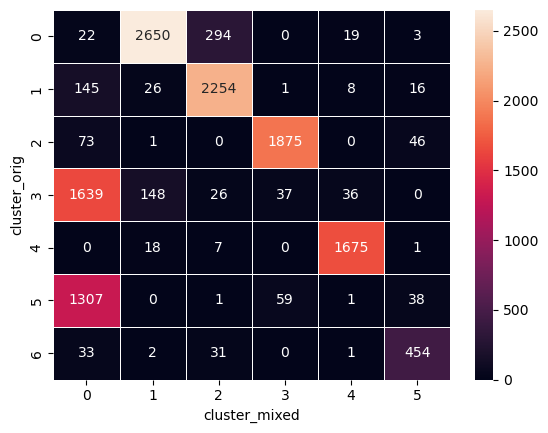

In [22]:
import pandas as pd
import seaborn as sns

m = data.merge(data_nocc, on="uid", how="inner", suffixes=("_or", "_mix"))
print(f"UID in comune: {len(m)}  |  out: {len(data)}  |  out_mixed: {len(data_nocc)}")


cm = pd.crosstab(m["leiden_r0.3_or"], m["leiden_r0.3_mix"],
                 rownames=["cluster_orig"], colnames=["cluster_mixed"])

print(cm)






sns.heatmap(cm,annot=True, fmt="d", linewidths=.5)